<a href="https://colab.research.google.com/github/cs23f012-web/CSL701-20-Machine-Learning-Lab/blob/main/CS20EXP6ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME:Apurva santosh jadhav
ROLL NO:CS20

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


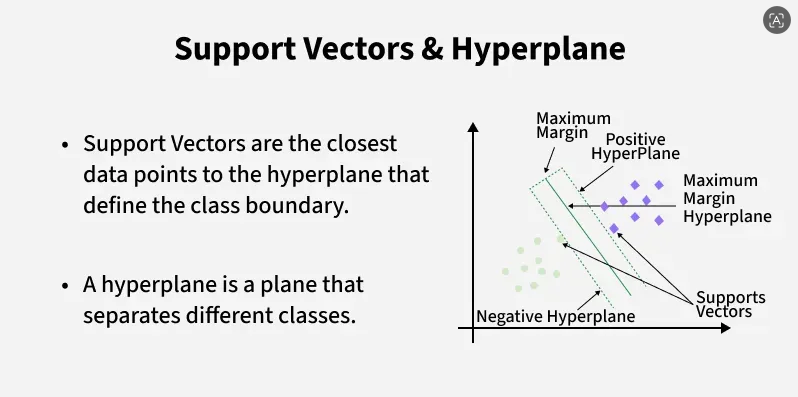
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load the Iris dataset from scikit-learn
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target column
df['species'] = iris.target

# Map integer targets to actual species names
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species_name'] = df['species'].map(species_map)

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# Task 2: Explore the Dataset

In [2]:
# Task 2: Explore the Dataset

# Display basic information about the DataFrame (column names, non-null counts, data types)
print("--- Dataset Info ---")
df.info()

# Display summary statistics for numerical features
print("\n--- Summary Statistics ---")
print(df.describe())

# Check shape (rows, columns)
print("\n--- Shape of Dataset ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# View class distribution
print("\n--- Target Class Distribution ---")
print(df['species_name'].value_counts())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

--- Summary Statistics ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%        

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [3]:
# Task 3: Select Features and Target

# Drop the 'Id' column if it exists in the DataFrame
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Select features (X) and target (y)
# Using feature columns: sepal length, sepal width, petal length, petal width
feature_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# If you loaded from a CSV with different column names (e.g. SepalLengthCm), use:
# feature_cols = [col for col in df.columns if col not in ['Id', 'Species', 'species', 'species_name']]

X = df[feature_cols]
y = df['species']

# Display selected features and target shape
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# View first 5 rows of features
X.head()

Features (X) shape: (150, 4)
Target (y) shape: (150,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [4]:
# Task 4: Split and Scale the Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Divide the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and fit StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display shapes of split datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [5]:
# Task 5: Implement Linear SVM

from sklearn.svm import SVC

# Create an SVM model with a linear kernel
svm_linear = SVC(kernel='linear', random_state=42)

# Fit the model on the scaled training data
svm_linear.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_svm = svm_linear.predict(X_test_scaled)

# Display predictions
print("Predictions:", y_pred_svm)

Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


Accuracy of Linear SVM: 100.00%

--- Confusion Matrix ---
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


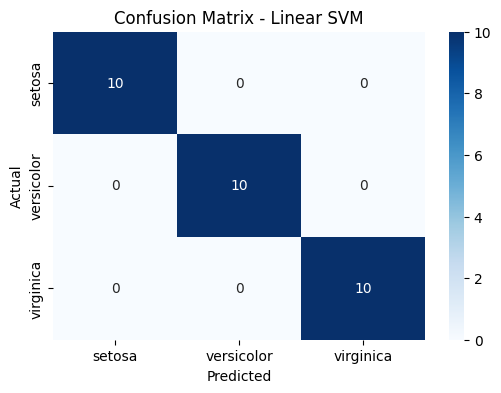


--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [6]:
# Task 6: Evaluate SVM

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy of Linear SVM: {accuracy * 100:.2f}%\n")

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
print("--- Confusion Matrix ---")
print(cm)

# Optionally plot the Confusion Matrix using Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Linear SVM')
plt.show()

# 3. Classification Report
print("\n--- Classification Report ---")
target_names = iris.target_names if 'iris' in globals() else ['setosa', 'versicolor', 'virginica']
print(classification_report(y_test, y_pred_svm, target_names=target_names))

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

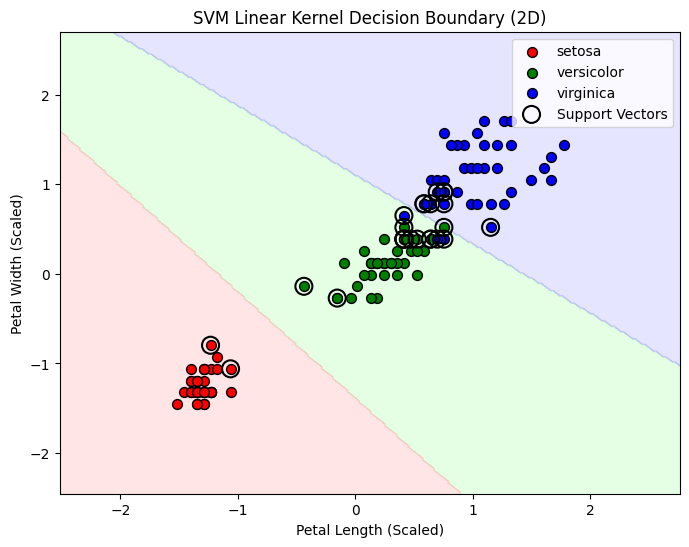

In [7]:
# Task 7: Visualize SVM Decision Boundary

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Create the 2-D Dataset (Petal Length and Petal Width)
X_2d = df[['petal length (cm)', 'petal width (cm)']]
y_2d = df['species']

# 2. Split the Data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)

# 3. Scale the Data
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# 4. Train SVM Classifier (Linear Kernel)
svm_2d = SVC(kernel='linear', random_state=42)
svm_2d.fit(X_train_2d_scaled, y_train_2d)

# 5. Plot Decision Boundary
def plot_decision_boundary(model, X, y, title):
    # Combine train data for complete plotting background
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    # Predict regions using the trained meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Custom colormaps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['red', 'green', 'blue']

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

    # Scatter plot data points
    for i, color in zip(range(3), cmap_bold):
        plt.scatter(
            X[y == i, 0], X[y == i, 1],
            c=color, label=iris.target_names[i],
            edgecolor='k', s=50
        )

    # Highlight Support Vectors
    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=150, facecolors='none', edgecolors='k',
        linewidths=1.5, label='Support Vectors'
    )

    plt.xlabel('Petal Length (Scaled)')
    plt.ylabel('Petal Width (Scaled)')
    plt.title(title)
    plt.legend()
    plt.show()

# Run visualization function
plot_decision_boundary(svm_2d, X_train_2d_scaled, y_train_2d.values, "SVM Linear Kernel Decision Boundary (2D)")

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

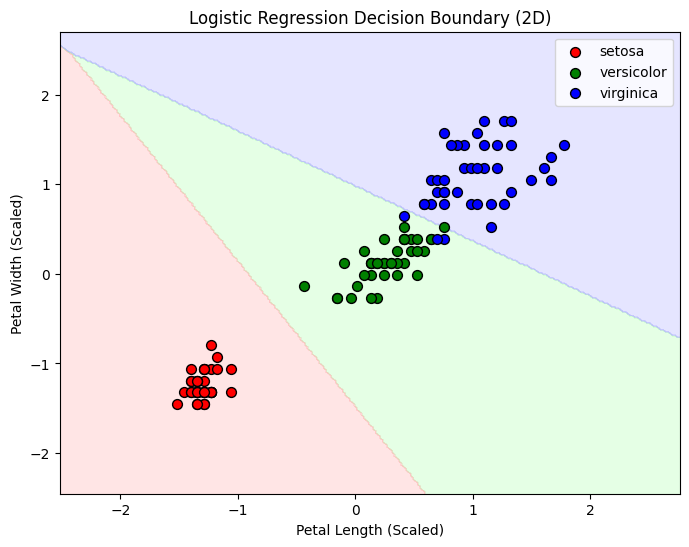

In [8]:
# Task 8: Normal Linear Classification Boundary

from sklearn.linear_model import LogisticRegression

# 1. Train Logistic Regression Classifier on the 2D scaled dataset
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_2d_scaled, y_train_2d)

# 2. Plot Decision Boundary for Logistic Regression
def plot_logistic_regression_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    # Predict regions
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Custom colormaps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['red', 'green', 'blue']

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

    # Scatter plot data points
    for i, color in zip(range(3), cmap_bold):
        plt.scatter(
            X[y == i, 0], X[y == i, 1],
            c=color, label=iris.target_names[i],
            edgecolor='k', s=50
        )

    plt.xlabel('Petal Length (Scaled)')
    plt.ylabel('Petal Width (Scaled)')
    plt.title(title)
    plt.legend()
    plt.show()

# Run visualization function
plot_logistic_regression_boundary(log_reg, X_train_2d_scaled, y_train_2d.values, "Logistic Regression Decision Boundary (2D)")

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

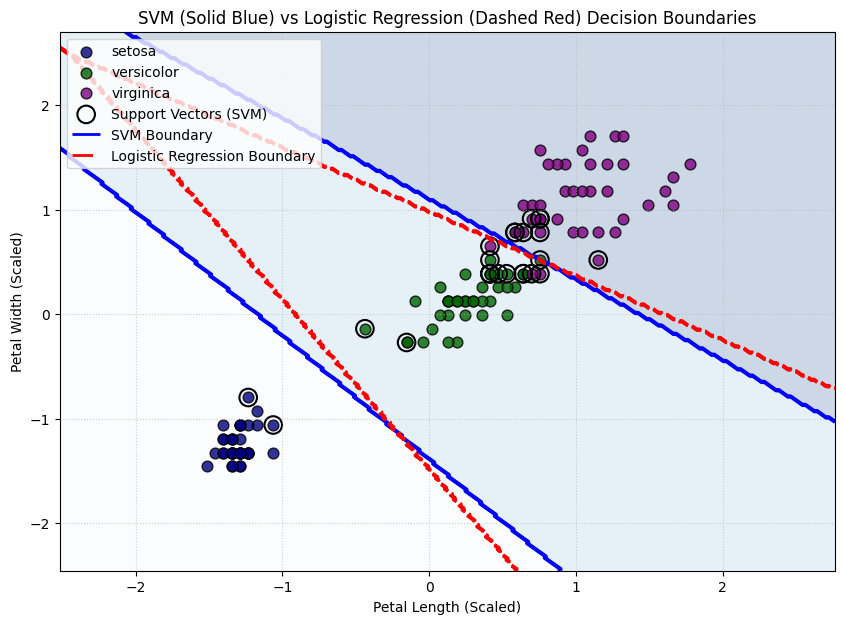

In [9]:
# Task 9: Compare SVM and Normal Boundary

import numpy as np
import matplotlib.pyplot as plt

# 1. Plot Decision Boundaries for both models on the same plot
def plot_comparison_boundaries(svm_model, log_model, X, y):
    # Set meshgrid limits
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    # Get predictions across grid
    Z_svm = svm_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    Z_log = log_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(10, 7))

    # Plot SVM background regions
    plt.contourf(xx, yy, Z_svm, alpha=0.2, cmap='Blues')

    # Plot Decision Boundary Lines (Contour lines where class changes)
    svm_contours = plt.contour(xx, yy, Z_svm, colors='blue', linewidths=2, linestyles='-')
    log_contours = plt.contour(xx, yy, Z_log, colors='red', linewidths=2, linestyles='--')

    # Scatter plot actual dataset points
    colors = ['navy', 'darkgreen', 'purple']
    for i, color in zip(range(3), colors):
        plt.scatter(
            X[y == i, 0], X[y == i, 1],
            c=color, label=iris.target_names[i],
            edgecolor='k', s=60, alpha=0.8
        )

    # Highlight SVM Support Vectors
    plt.scatter(
        svm_model.support_vectors_[:, 0],
        svm_model.support_vectors_[:, 1],
        s=160, facecolors='none', edgecolors='black',
        linewidths=1.5, label='Support Vectors (SVM)'
    )

    # Custom Legend for Decision Boundary Lines
    h1, _ = svm_contours.legend_elements()
    h2, _ = log_contours.legend_elements()

    plt.xlabel('Petal Length (Scaled)')
    plt.ylabel('Petal Width (Scaled)')
    plt.title('SVM (Solid Blue) vs Logistic Regression (Dashed Red) Decision Boundaries')

    # Place existing legend and add line legend entries
    handles, labels = plt.gca().get_legend_handles_labels()
    handles.extend([h1[0], h2[0]])
    labels.extend(['SVM Boundary', 'Logistic Regression Boundary'])

    plt.legend(handles=handles, labels=labels, loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Execute plot function
plot_comparison_boundaries(svm_2d, log_reg, X_train_2d_scaled, y_train_2d.values)

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [10]:
# Task 10: Compare Performance

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# 1. Predictions for both models (using full scaled feature set)
# Training Logistic Regression on full feature set for fair comparison
from sklearn.linear_model import LogisticRegression

log_reg_full = LogisticRegression(random_state=42)
log_reg_full.fit(X_train_scaled, y_train)

y_pred_svm = svm_linear.predict(X_test_scaled)
y_pred_log = log_reg_full.predict(X_test_scaled)

target_names = iris.target_names if 'iris' in globals() else ['setosa', 'versicolor', 'virginica']

# 2. Accuracy Comparison
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_log = accuracy_score(y_test, y_pred_log)

print("="*50)
print("ACCURACY COMPARISON")
print("="*50)
print(f"Linear SVM Accuracy:          {acc_svm * 100:.2f}%")
print(f"Logistic Regression Accuracy: {acc_log * 100:.2f}%\n")

# 3. Confusion Matrix Comparison
print("="*50)
print("CONFUSION MATRIX COMPARISON")
print("="*50)
print("\n--- Linear SVM Confusion Matrix ---")
print(pd.DataFrame(confusion_matrix(y_test, y_pred_svm), index=target_names, columns=target_names))

print("\n--- Logistic Regression Confusion Matrix ---")
print(pd.DataFrame(confusion_matrix(y_test, y_pred_log), index=target_names, columns=target_names))

# 4. Classification Report Comparison
print("\n" + "="*50)
print("CLASSIFICATION REPORT COMPARISON")
print("="*50)

print("\n--- Linear SVM Classification Report ---")
print(classification_report(y_test, y_pred_svm, target_names=target_names))

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_log, target_names=target_names))

ACCURACY COMPARISON
Linear SVM Accuracy:          100.00%
Logistic Regression Accuracy: 93.33%

CONFUSION MATRIX COMPARISON

--- Linear SVM Confusion Matrix ---
            setosa  versicolor  virginica
setosa          10           0          0
versicolor       0          10          0
virginica        0           0         10

--- Logistic Regression Confusion Matrix ---
            setosa  versicolor  virginica
setosa          10           0          0
versicolor       0           9          1
virginica        0           1          9

CLASSIFICATION REPORT COMPARISON

--- Linear SVM Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.